<a href="https://colab.research.google.com/github/rahminurulainunfitrah/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAMA: RAHMI NURUL AINUN FITRAH**

**NIM: M0501251014**

**TUGAS 2 PRAKTIKUM ANALISIS DERET WAKTU**

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [427]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [482]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1014)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 * 14
beta0 = 10 + 14
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


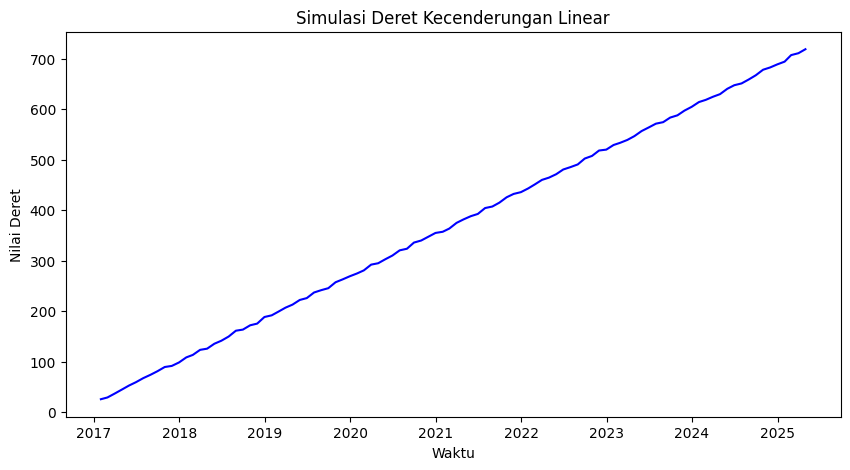

In [483]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

**Jawab:** Berdasarkan grafik, deret waktu menunjukkan adanya kecenderungan linear positif yang kuat, ditandai dengan peningkatan nilai deret secara konsisten dari tahun 2017 hingga 2025. Fluktuasi di sekitar kecenderungan tersebut relatif kecil dan tidak terlihat pola musiman yang jelas. Kondisi ini mengindikasikan bahwa deret belum stasioner pada level karena terdapat trend, sehingga diperlukan transformasi atau differencing sebelum dilakukan pemodelan time series lebih lanjut.

**Cek apakah ada korelasi antar pengamatan?**

In [484]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


**Jawab:** Nilai korelasi antara Time dan Value sebesar 1,0000 menunjukkan adanya hubungan linear positif sempurna. Hal ini mengindikasikan bahwa peningkatan waktu diikuti oleh peningkatan nilai secara konsisten dengan pola yang hampir linear. Dengan demikian, deret memiliki kecenderungan linear positif yang sangat kuat dan mengindikasikan adanya trend dalam data.

In [485]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.131e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.00e-201
Time:                        12:20:34   Log-Likelihood:                -205.07
No. Observations:                 100   AIC:                             414.1
Df Residuals:                      98   BIC:                             419.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           24.0402      0.377     63.741   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**

**Jawab:** Berdasarkan hasil pengepasan model regresi, diperoleh estimasi parameter $\hat{\beta}_0=24,0402$ dan $\hat{\beta}_1=7.0012$. Nilai tersebut sangat dekat dengan parameter asli yang digunakan dalam simulasi, yaitu $\beta_0=24$ dan $\beta_1=7$ . Selisih antara parameter asli dan hasil estimasi relatif sangat kecil, sehingga dapat dikatakan bahwa metode OLS mampu mengestimasi parameter model dengan sangat baik.

**Apakah model regresi yang dipaskan sudah bagus?**

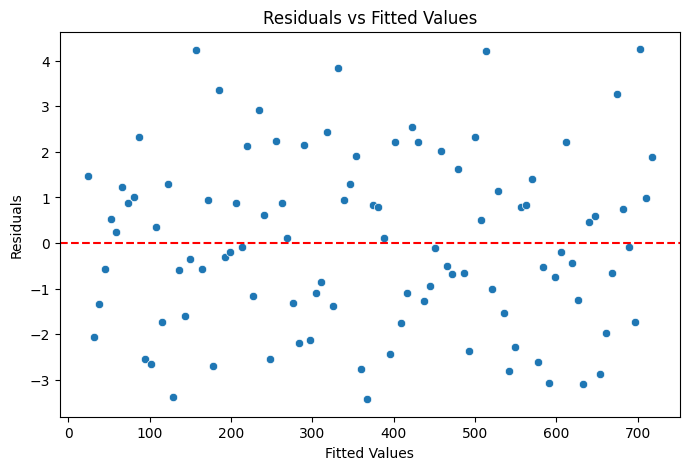

In [432]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

**Jawab:** Berdasarkan **plot Residuals vs Fitted Values**, residual terlihat menyebar secara acak di sekitar garis nol dan tidak menunjukkan pola tertentu. Penyebaran residual juga relatif konstan pada berbagai nilai fitted values. Hal ini menunjukkan bahwa asumsi linearitas dan homoskedastisitas secara visual cukup terpenuhi. Dengan demikian, model regresi yang digunakan dapat dikatakan sudah cukup baik dalam menggambarkan hubungan antara waktu dan nilai deret.

In [433]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.5140


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

**Jawab:**

**Nilai p-value Breusch–Pagan Test = 0,5140.**

Hipotesis:

$H_0$: varians residual konstan (homoskedastisitas)

$H_1$: varians residual tidak konstan (heteroskedastisitas)

Karena:

$ p\text{-value}=0,5140 > 0,05 $ maka gagal tolak $H_0$.

**Kesimpulan:** Tidak terdapat bukti yang cukup untuk menyatakan adanya heteroskedastisitas pada residual. Dengan demikian, residual dapat dianggap memiliki varians yang konstan (homoskedastisitas).

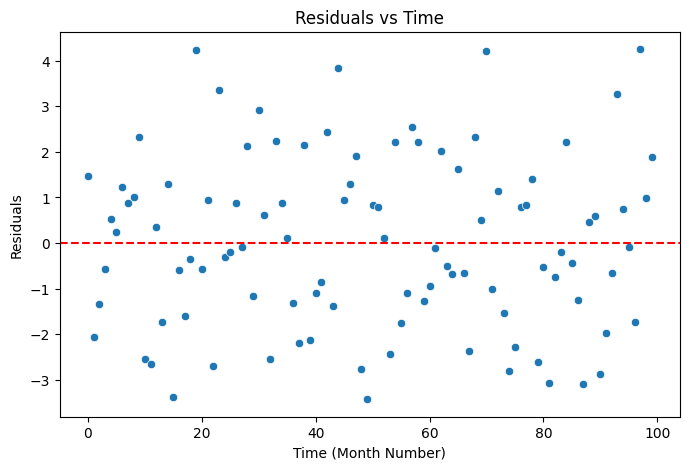

In [434]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


**Interpretasi:** Plot Residuals vs Time menunjukkan bahwa residual tersebar secara acak di sekitar nilai nol dan tidak memperlihatkan pola atau tren tertentu terhadap waktu. Penyebaran residual juga relatif konstan sepanjang periode pengamatan. Dengan demikian, secara visual residual dapat dikatakan tidak menunjukkan adanya pola temporal yang sistematis dan model relatif mampu menangkap pola pada data runtun waktu. Namun, plot ini saja belum cukup untuk memastikan tidak adanya autokorelasi. Untuk data runtun waktu, sebaiknya dilengkapi dengan plot ACF residual dan uji Ljung–Box. Jika uji Ljung–Box menghasilkan $p\text{-value}>0{,}05$, maka tidak terdapat bukti yang cukup adanya autokorelasi residual.

<Figure size 800x500 with 0 Axes>

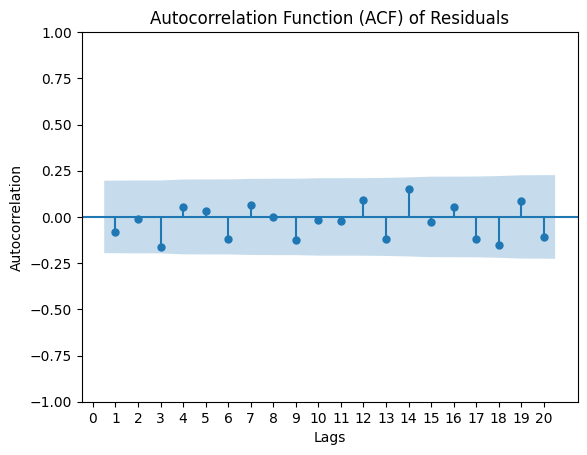

In [435]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**

**Jawab:** Plot ACF menunjukkan bahwa residual tidak memiliki autokorelasi yang signifikan pada **lag 1–20**. Hal ini mengindikasikan bahwa residual antarperiode relatif independen dan model telah mampu menangkap pola ketergantungan waktu dalam data.

In [436]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.678230   0.410197
2    0.687073   0.709258
3    3.507368   0.319808
4    3.839523   0.428160
5    3.935103   0.558797
6    5.448966   0.487646
7    5.907332   0.550611
8    5.907401   0.657604
9    7.701265   0.564509
10   7.733573   0.654843
11   7.787581   0.732196
12   8.809522   0.719108
13  10.532974   0.649878
14  13.206908   0.510300
15  13.298511   0.579253
16  13.650451   0.624737
17  15.460374   0.562358
18  18.401741   0.429497
19  19.368484   0.433437


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?**

**Jawab:**

Hipotesis:

$H_0$: Tidak terdapat autokorelasi residual hingga lag tertentu.

$H_1$: Terdapat autokorelasi residual hingga lag tertentu.

Taraf signifikansi: $\alpha=0{,}05$.

Dari hasil pengujian, seluruh p-value pada lag 1–19 lebih besar dari 0,05. Sebagai contoh, pada lag 1 diperoleh $p\text{-value}=0{,}4102$, sedangkan pada lag 19 diperoleh $p\text{-value}=0{,}4334$. P-value terkecil yang diperoleh adalah sekitar $0,3198$ pada $lag-3$, yang tetap lebih besar dari $0,05$.

Dengan demikian, pada seluruh lag yang diuji gagal menolak $H_0$.

Berdasarkan uji Ljung–Box, diperoleh p-value > 0,05 pada seluruh lag 1–19. Oleh karena itu, $H_0$ tidak ditolak, sehingga tidak terdapat bukti yang signifikan mengenai adanya autokorelasi pada residual. Hal ini menunjukkan bahwa residual bersifat relatif independen atau menyerupai white noise. Hasil ini konsisten dengan plot ACF yang menunjukkan seluruh nilai autokorelasi berada dalam batas interval kepercayaan. Dengan demikian, asumsi independensi residual pada model telah terpenuhi.

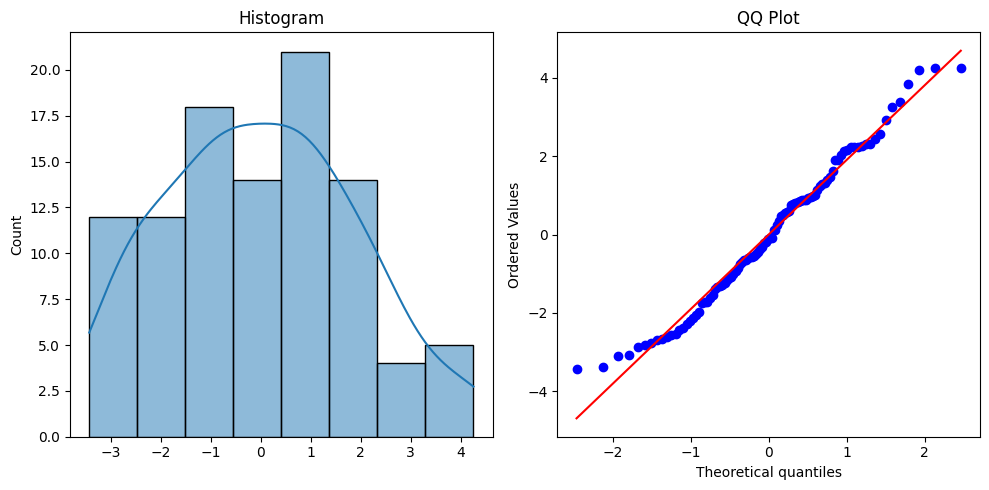

In [437]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?**
**Jawab:** Histogram dan Q-Q plot menunjukkan bahwa residual secara umum mendekati distribusi normal, yang ditunjukkan oleh sebagian besar titik pada Q-Q plot yang mengikuti garis diagonal. Meskipun demikian, terdapat beberapa penyimpangan pada bagian ekor distribusi, terutama pada ekor kanan, yang mengindikasikan adanya residual ekstrem dan sedikit penyimpangan dari asumsi normalitas. Secara keseluruhan, penyimpangan tersebut tidak terlalu dominan sehingga normalitas residual secara umum masih dapat dianggap terpenuhi, namun perlu dikonfirmasi dengan uji formal normalitas.

In [438]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.978718334175163, p-value = 0.1055732580365466


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?**
**Jawab:**
Hasil uji Shapiro–Wilk tersebut menunjukkan:

Statistik uji:
$W = 0{,}9787$
$p\text{-value} = 0{,}1056$
$\alpha = 0{,}05$

Hipotesisnya:

$$ H_0:\text{ residual berdistribusi normal} $$ $$ H_1:\text{ residual tidak berdistribusi normal} $$

Karena

$$ 0{,}1056 > 0{,}05, $$

maka gagal tolak $H_0$. Artinya, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal.

Hasil ini konsisten dengan Q-Q plot sebelumnya. Walaupun terlihat beberapa penyimpangan pada bagian ekor, secara statistik penyimpangan tersebut tidak cukup kuat untuk menolak asumsi normalitas.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [439]:
# Menentukan parameter simulasi
np.random.seed(1014)
n_periods = 120
beta_0, beta_1, beta_2= 50+14, 0.5*14, 0.02*14
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

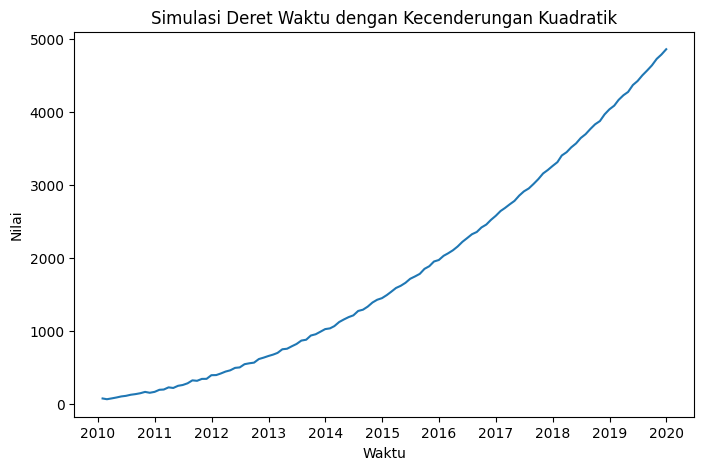

In [440]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

**Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?**

**Jawab:** Deret dengan kecenderungan kuadratik menunjukkan tren meningkat yang semakin cepat, ditandai oleh kurva yang semakin curam seiring bertambahnya waktu. Berbeda dengan deret dengan kecenderungan linear yang meningkat secara relatif konstan dan membentuk pola garis lurus. Dengan demikian, perbedaan utama kedua deret terletak pada laju perubahan nilainya: pada tren linear laju perubahan relatif konstan, sedangkan pada tren kuadratik laju perubahan semakin meningkat dari waktu ke waktu.

In [441]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.363e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.19e-256
Time:                        12:17:22   Log-Likelihood:                -438.60
No. Observations:                 120   AIC:                             883.2
Df Residuals:                     117   BIC:                             891.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.3351      2.552     24.815      0.0

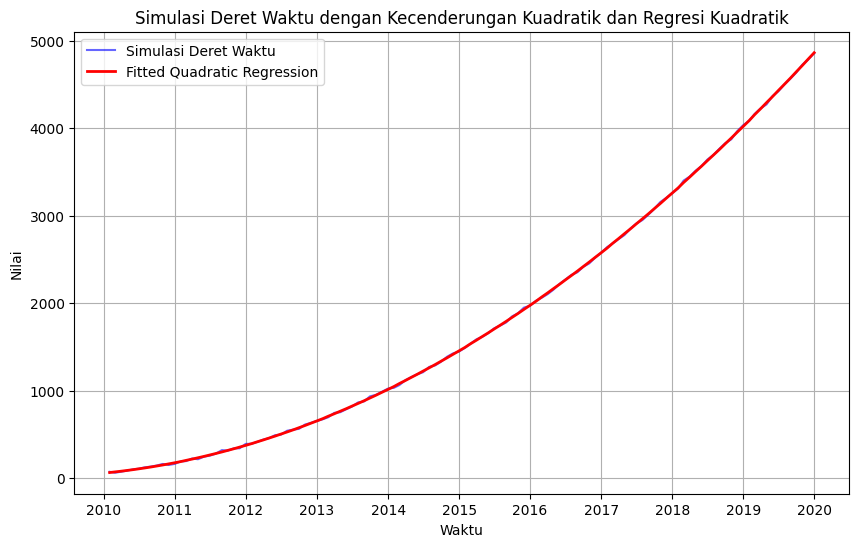

In [442]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

**Jawab:** Berdasarkan hasil OLS dan pemeriksaan diagnostik, model regresi kuadratik secara umum telah memenuhi asumsi normalitas dan independensi residual. Normalitas residual ditunjukkan oleh uji Jarque-Bera dengan $p=0{,}320>0{,}05$, serta diperkuat oleh uji Shapiro-Wilk dengan $p=0{,}1056>0{,}05$. Independensi residual ditunjukkan oleh nilai Durbin-Watson sebesar 2,182, plot ACF yang tidak menunjukkan spike signifikan, dan uji Ljung-Box yang menghasilkan $p>0{,}05$ pada seluruh lag yang diuji. Bentuk kuadratik juga sesuai dengan pola deret dan koefisien $t^2$ signifikan. Namun, asumsi homoskedastisitas belum dapat dipastikan secara formal karena belum dilakukan uji heteroskedastisitas seperti Breusch-Pagan.

In [486]:
# Uji Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_quad.resid, model_quad.model.exog)

# Menampilkan hasil
print("Breusch-Pagan Test")
print(f"LM Statistic : {bp_test[0]:.6f}")
print(f"LM p-value   : {bp_test[1]:.6f}")
print(f"F Statistic  : {bp_test[2]:.6f}")
print(f"F p-value    : {bp_test[3]:.6f}")

Breusch-Pagan Test
LM Statistic : 0.552573
LM p-value   : 0.758596
F Statistic  : 0.270625
F p-value    : 0.763379


Hasil Breusch–Pagan Test menunjukkan bahwa asumsi homoskedastisitas terpenuhi.

Hipotesis
$H_0$: varians residual konstan (homoskedastisitas)

$H_1$: terdapat heteroskedastisitas

Dengan $alpha=0{,}05\$

LM p-value = 0,758596

F-test p-value = 0,763379 **bold text**

Keduanya jauh lebih besar dari 0,05.

$$ 0{,}758596>0{,}05 $$

dan

$$ 0{,}763379>0{,}05. $$
Keputusan

Karena $p\text{-value}>0,05$, maka $H_0$ gagal ditolak.

Artinya, tidak terdapat bukti yang cukup untuk menyatakan adanya heteroskedastisitas.

**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**

**Jawab:** Model regresi kuadratik yang dipaskan terhadap deret sudah tepat. Hal ini ditunjukkan oleh kesesuaian bentuk model dengan pola deret yang memiliki kecenderungan meningkat semakin cepat, serta signifikannya komponen kuadratik $p<0,001$. Model juga memiliki $R^2=1,000$, yang menunjukkan kemampuan penjelasan yang sangat tinggi. Berdasarkan pemeriksaan residual, asumsi normalitas, independensi, dan homoskedastisitas juga terpenuhi. Dengan demikian, tidak ditemukan pelanggaran asumsi yang berarti dan model regresi kuadratik mampu menggambarkan pola deret dengan baik.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [444]:
# Menentukan parameter simulasi
np.random.seed(1014)
n_periods = 120
beta0, beta1, beta2=50+14,-25*14, -2*14
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


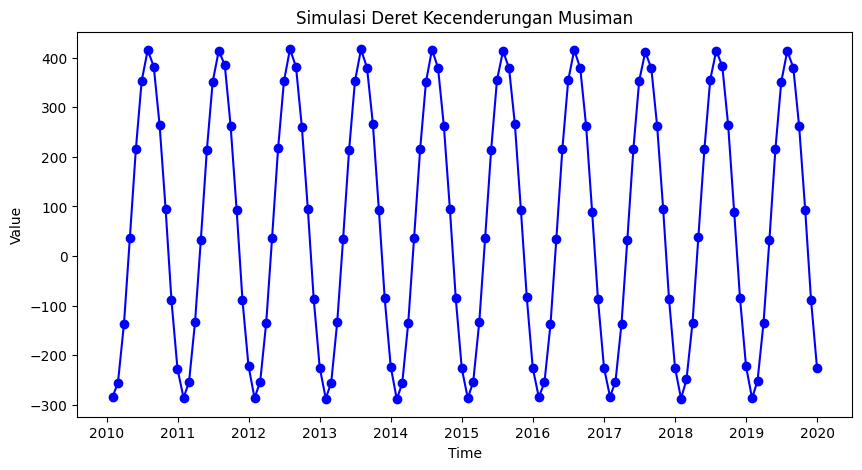

In [445]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


**Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?**

**Jawab:** Deret menunjukkan pola musiman yang sangat kuat dengan periode 12, yang ditandai oleh pola naik-turun yang berulang secara konsisten setiap 12 periode. Puncak dan lembah terjadi pada posisi yang relatif sama setiap tahun dengan amplitudo yang relatif konstan. Deret juga tidak menunjukkan kecenderungan tren jangka panjang yang berarti. Dengan demikian, karakteristik utama deret adalah pola musiman bulanan yang stabil dan berulang setiap tahun.

In [446]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [447]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [448]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [449]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.895e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.57e-226
Time:                        12:17:23   Log-Likelihood:                -239.97
No. Observations:                 120   AIC:                             503.9
Df Residuals:                     108   BIC:                             537.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -286.1695      0.596   -480.293      0.0

**Bagaimana interpretasi dari hasil tersebut?**

**Jawab:** Hasil regresi menunjukkan bahwa model dengan komponen musiman 12 bulan mampu menggambarkan pola deret dengan sangat baik, ditunjukkan oleh nilai $R^2$ dan Adjusted $R^2$ sebesar 1,000 serta uji F yang signifikan $p<0,001$. Pola musiman terlihat jelas, dengan nilai cenderung meningkat dari Januari hingga mencapai puncak pada Juli, kemudian menurun hingga Desember. Seluruh koefisien bulan signifikan secara statistik. Dari diagnostik residual, nilai Durbin-Watson sebesar 2,132 serta uji Omnibus dan Jarque-Bera yang menghasilkan $p>0,05$ menunjukkan bahwa residual tidak menunjukkan indikasi kuat autokorelasi maupun penyimpangan dari normalitas. Dengan demikian, model musiman periode 12 sudah sangat baik dalam menangkap pola musiman pada deret.

In [450]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

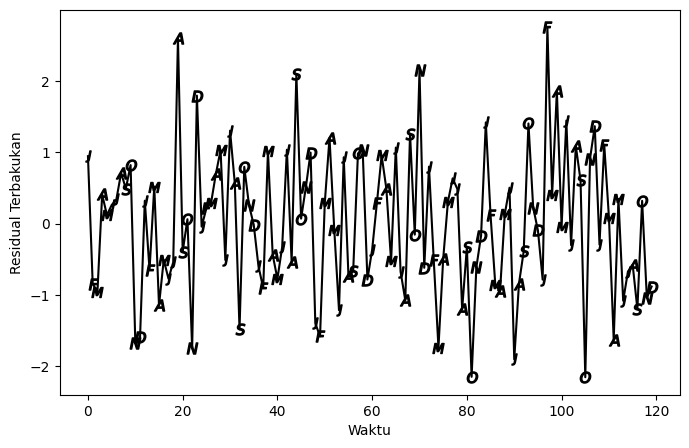

In [451]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


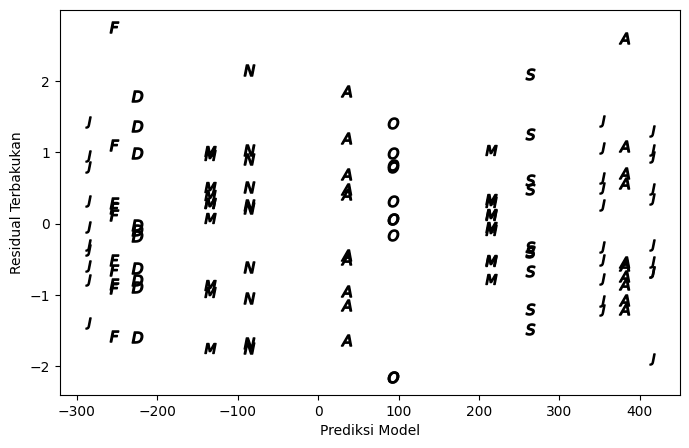

In [452]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

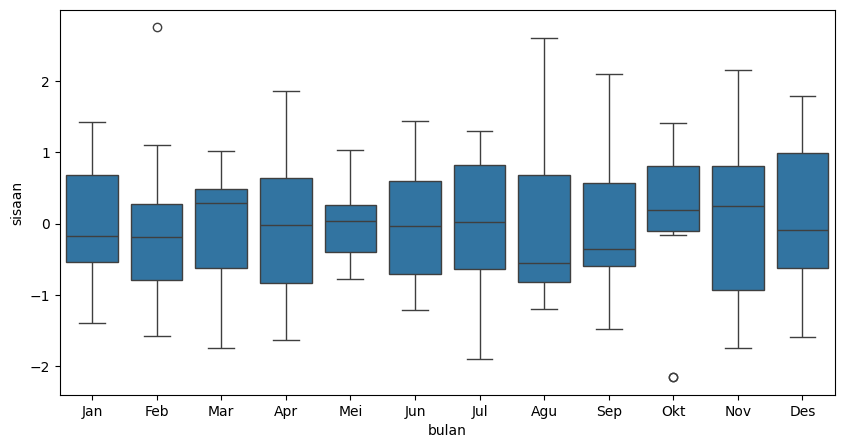

In [453]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

**Bagaimana interpretasi Anda terhadap tiga plot di atas?**

**Jawab:** Residual cenderung tersebar secara acak di sekitar nol baik terhadap waktu maupun nilai prediksi model. Tidak terlihat pola sistematis, pola musiman yang tersisa, maupun pola kipas yang kuat. Boxplot residual berdasarkan bulan juga menunjukkan bahwa median residual pada setiap bulan berada di sekitar nol. Dengan demikian, model musiman periode 12 telah mampu menangkap pola utama pada deret dengan baik. Meskipun terdapat beberapa pencilan, pencilan tersebut relatif terbatas dan tidak menunjukkan pola tertentu.

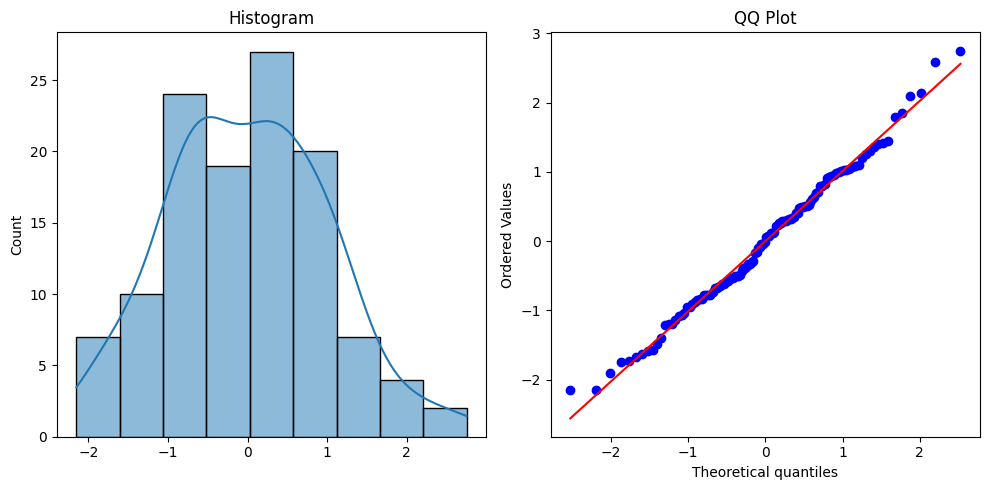

In [454]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?**

**Jawab:** Berdasarkan histogram dan Q-Q plot, residual model berdistribusi mendekati normal. Hal ini ditunjukkan oleh histogram yang relatif berbentuk lonceng dan titik-titik pada Q-Q plot yang sebagian besar mengikuti garis diagonal. Hasil tersebut juga diperkuat oleh uji Shapiro-Wilk dan Jarque-Bera yang menghasilkan $p\text{-value}>0,05$. Dengan demikian, asumsi normalitas residual dapat dianggap terpenuhi.

**Hitunglah statistik uji untuk mengecek asumsi model**

In [455]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [456]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [457]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.895e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.57e-226
Time:                        12:17:25   Log-Likelihood:                -239.97
No. Observations:                 120   AIC:                             503.9
Df Residuals:                     108   BIC:                             537.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -286.1695      0.596   -480.293      0.0

**Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!**

**Jawab:** Pengepasan model musiman dengan intersep menggunakan Januari sebagai kategori referensi, sedangkan model tanpa intersep menggunakan seluruh 12 kategori bulan. Pada model tanpa intersep, setiap koefisien dapat diinterpretasikan secara langsung sebagai rata-rata nilai deret pada masing-masing bulan. Sementara itu, pada model dengan intersep, intersep merepresentasikan rata-rata nilai pada bulan Januari, sedangkan koefisien dummy bulan lainnya menunjukkan selisih rata-rata nilai bulan tersebut terhadap Januari. Sebagai contoh, koefisien Juli sebesar 700,8393 berarti bahwa nilai pada bulan Juli rata-rata 700,8393 unit lebih tinggi dibandingkan Januari. Jika dijumlahkan dengan intersep \(-286,1695\), diperoleh nilai Juli sebesar 414,6698, yang sama dengan koefisien Juli pada model tanpa intersep. Dengan demikian, kedua model memberikan hasil fitted yang ekuivalen, tetapi memiliki interpretasi parameter yang berbeda.

**Apakah model dengan intersep sudah memenuhi asumsi regresi?**

**Jawab:** Berdasarkan hasil pengujian asumsi regresi, residual berdistribusi normal yang ditunjukkan oleh nilai Jarque-Bera sebesar 0,944 dengan probabilitas 0,624 > 0,05. Nilai Durbin-Watson sebesar 2,132 yang mendekati 2 menunjukkan tidak terdapat indikasi autokorelasi. Secara visual, plot residual terhadap waktu dan nilai prediksi tidak menunjukkan pola sistematis yang kuat. Namun, boxplot residual berdasarkan bulan menunjukkan adanya perbedaan penyebaran residual antarbulan, sehingga asumsi homoskedastisitas perlu dikonfirmasi lebih lanjut menggunakan uji Breusch-Pagan. Dengan demikian, secara umum model telah memenuhi sebagian besar asumsi OLS, tetapi homoskedastisitas masih perlu mendapatkan perhatian.

In [488]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Prepare the exogenous variables for the Breusch-Pagan test by explicitly adding a constant
# 'season' is the DataFrame used as exog when fitting model_mix
exog_for_bp_test = sm.add_constant(season, prepend=True)

# Uji Breusch-Pagan for model_mix
bp_test_mix = het_breuschpagan(model_mix.resid, exog_for_bp_test)

print("Breusch-Pagan Test for model_mix")
print(f"LM Statistic : {bp_test_mix[0]:.6f}")
print(f"LM p-value   : {bp_test_mix[1]:.6f}")
print(f"F Statistic  : {bp_test_mix[2]:.6f}")
print(f"F p-value    : {bp_test_mix[3]:.6f}")

Breusch-Pagan Test for model_mix
LM Statistic : 6.807837
LM p-value   : 0.911781
F Statistic  : 0.529624
F p-value    : 0.889978


Berdasarkan uji Breusch-Pagan, diperoleh nilai LM sebesar 6,808 dengan p-value sebesar 0,912. Karena p-value > 0,05, maka $H_0$ tidak ditolak, sehingga tidak terdapat indikasi heteroskedastisitas pada model. Dengan demikian, asumsi homoskedastisitas terpenuhi. Hasil ini juga didukung oleh F-statistic sebesar 0,530 dengan p-value sebesar 0,890 yang menunjukkan kesimpulan yang sama.

In [495]:
# uji asumsi model dengan intersep

import statsmodels.api as sm
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# Residual model
residual_int = musiman_int.resid


# 1. UJI NORMALITAS - JARQUE BERA

jb_stat, jb_pvalue = jarque_bera(residual_int)

print("=" * 50)
print("UJI NORMALITAS - JARQUE BERA")
print("=" * 50)
print("JB Statistic :", jb_stat)
print("JB p-value   :", jb_pvalue)

if jb_pvalue > 0.05:
    print("Keputusan    : Residual berdistribusi normal")
else:
    print("Keputusan    : Residual tidak berdistribusi normal")


# 2. UJI HETEROSKEDASTISITAS - BREUSCH PAGAN

# Gunakan variabel independen model + konstanta
X_bp_int = musiman_int.model.exog

bp_int = het_breuschpagan(residual_int, X_bp_int)

print("\n" + "=" * 50)
print("UJI HETEROSKEDASTISITAS - BREUSCH PAGAN")
print("=" * 50)
print("LM Statistic :", bp_int[0])
print("LM p-value   :", bp_int[1])
print("F Statistic  :", bp_int[2])
print("F p-value    :", bp_int[3])

if bp_int[1] > 0.05:
    print("Keputusan    : Tidak terdapat heteroskedastisitas")
else:
    print("Keputusan    : Terdapat heteroskedastisitas")


# 3. UJI AUTOKORELASI - DURBIN WATSON

dw_int = durbin_watson(residual_int)

print("\n" + "=" * 50)
print("UJI AUTOKORELASI - DURBIN WATSON")
print("=" * 50)
print("Durbin-Watson :", dw_int)

if 1.5 < dw_int < 2.5:
    print("Keputusan    : Tidak terdapat indikasi autokorelasi")
else:
    print("Keputusan    : Terdapat indikasi autokorelasi")


# 4. UJI AUTOKORELASI - LJUNG BOX

lb_int = acorr_ljungbox(
    residual_int,
    lags=[12],
    return_df=True
)

print("\n" + "=" * 50)
print("UJI AUTOKORELASI - LJUNG BOX")
print("=" * 50)
print(lb_int)

if lb_int['lb_pvalue'].iloc[0] > 0.05:
    print("Keputusan    : Tidak terdapat autokorelasi")
else:
    print("Keputusan    : Terdapat autokorelasi")

UJI NORMALITAS - JARQUE BERA
JB Statistic : 0.9444603628209169
JB p-value   : 0.6236099529774187
Keputusan    : Residual berdistribusi normal

UJI HETEROSKEDASTISITAS - BREUSCH PAGAN
LM Statistic : 7.753094819909143
LM p-value   : 0.7352356676995982
F Statistic  : 0.6781594064739809
F p-value    : 0.7564600140765374
Keputusan    : Tidak terdapat heteroskedastisitas

UJI AUTOKORELASI - DURBIN WATSON
Durbin-Watson : 2.1316425154154266
Keputusan    : Tidak terdapat indikasi autokorelasi

UJI AUTOKORELASI - LJUNG BOX
     lb_stat  lb_pvalue
12  4.443279   0.974046
Keputusan    : Tidak terdapat autokorelasi


Berdasarkan hasil pengujian asumsi model regresi dengan intersep, diperoleh bahwa residual berdistribusi normal, tidak terdapat gejala heteroskedastisitas, serta tidak terdapat autokorelasi. Dengan demikian, model regresi dengan intersep telah memenuhi seluruh asumsi yang diuji dan layak digunakan untuk analisis lebih lanjut.

## Kecenderungan Linear dan Musiman

In [459]:
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*14, 10*14 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


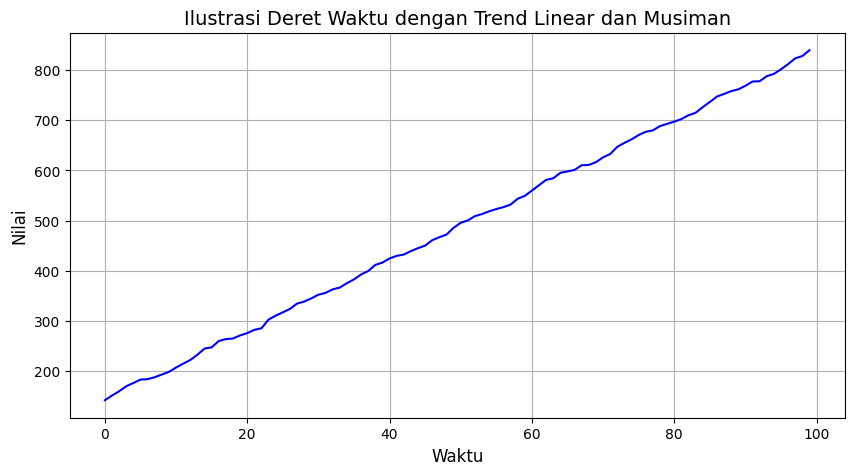

In [460]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [461]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [462]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [463]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.073e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.04e-172
Time:                        12:17:26   Log-Likelihood:                -200.88
No. Observations:                 100   AIC:                             427.8
Df Residuals:                      87   BIC:                             461.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      140.1295      0.721    194.437      0.0

**Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?**

**Jawab:** Berdasarkan hasil estimasi regresi, koefisien variabel period sebesar 6,9936 menunjukkan bahwa setiap peningkatan satu periode waktu diperkirakan meningkatkan nilai variabel dependen sebesar 6,9936 satuan, dengan mempertahankan pola musiman bulanan. Koefisien tersebut signifikan secara statistik pada taraf 5% dengan p-value sebesar 0,000. Sementara itu, koefisien dummy bulan menunjukkan adanya perbedaan tingkat nilai antarbulan. Koefisien terbesar terdapat pada bulan Mei sebesar 145,3789, sedangkan koefisien terkecil terdapat pada bulan Oktober sebesar 135,1002. Hal tersebut menunjukkan bahwa selain memiliki kecenderungan meningkat secara linear dari waktu ke waktu, data juga memiliki pola musiman berdasarkan bulan.

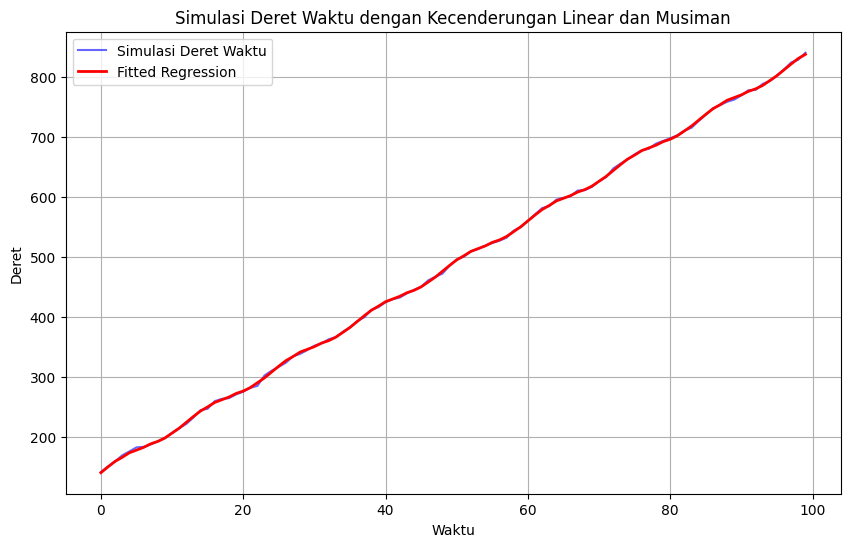

In [464]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [494]:
# UJI ASUMSI MODEL MIX

import statsmodels.api as sm
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# Residual model
residual = model_mix.resid


# 1. UJI NORMALITAS - JARQUE BERA

jb_stat, jb_pvalue = jarque_bera(residual)

print("=" * 50)
print("UJI NORMALITAS - JARQUE BERA")
print("=" * 50)
print("JB Statistic :", jb_stat)
print("JB p-value   :", jb_pvalue)

if jb_pvalue > 0.05:
    print("Keputusan    : Residual berdistribusi normal")
else:
    print("Keputusan    : Residual tidak berdistribusi normal")


# 2. UJI HETEROSKEDASTISITAS - BREUSCH PAGAN

# Gunakan exog dari model dan tambahkan konstanta
X_bp = sm.add_constant(model_mix.model.exog)

bp = het_breuschpagan(residual, X_bp)

print("\n" + "=" * 50)
print("UJI HETEROSKEDASTISITAS - BREUSCH PAGAN")
print("=" * 50)
print("LM Statistic :", bp[0])
print("LM p-value   :", bp[1])
print("F Statistic  :", bp[2])
print("F p-value    :", bp[3])

if bp[1] > 0.05:
    print("Keputusan    : Tidak terdapat heteroskedastisitas")
else:
    print("Keputusan    : Terdapat heteroskedastisitas")


# 3. UJI AUTOKORELASI - DURBIN WATSON

dw = durbin_watson(residual)

print("\n" + "=" * 50)
print("UJI AUTOKORELASI - DURBIN WATSON")
print("=" * 50)
print("Durbin-Watson :", dw)

if 1.5 < dw < 2.5:
    print("Keputusan    : Tidak terdapat indikasi autokorelasi")
else:
    print("Keputusan    : Terdapat indikasi autokorelasi")


# 4. UJI AUTOKORELASI - LJUNG BOX

lb = acorr_ljungbox(
    residual,
    lags=[12],
    return_df=True
)

print("\n" + "=" * 50)
print("UJI AUTOKORELASI - LJUNG BOX")
print("=" * 50)
print(lb)

if lb['lb_pvalue'].iloc[0] > 0.05:
    print("Keputusan    : Tidak terdapat autokorelasi")
else:
    print("Keputusan    : Terdapat autokorelasi")

UJI NORMALITAS - JARQUE BERA
JB Statistic : 0.04841553373052749
JB p-value   : 0.9760828910066288
Keputusan    : Residual berdistribusi normal

UJI HETEROSKEDASTISITAS - BREUSCH PAGAN
LM Statistic : 6.807837384332672
LM p-value   : 0.9117808775406012
F Statistic  : 0.5296241620656849
F p-value    : 0.8899782703940966
Keputusan    : Tidak terdapat heteroskedastisitas

UJI AUTOKORELASI - DURBIN WATSON
Durbin-Watson : 2.0054794092317274
Keputusan    : Tidak terdapat indikasi autokorelasi

UJI AUTOKORELASI - LJUNG BOX
      lb_stat  lb_pvalue
12  12.180722   0.431277
Keputusan    : Tidak terdapat autokorelasi


Berdasarkan hasil uji asumsi model_mix, dapat disimpulkan bahwa model telah memenuhi seluruh asumsi yang diuji. Residual model berdistribusi normal, tidak terdapat masalah heteroskedastisitas, serta tidak terdapat indikasi autokorelasi berdasarkan uji Durbin-Watson maupun Ljung-Box. Dengan demikian, model_mix dapat dinyatakan memenuhi asumsi dasar yang diperlukan untuk analisis regresi yang dilakukan.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [466]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

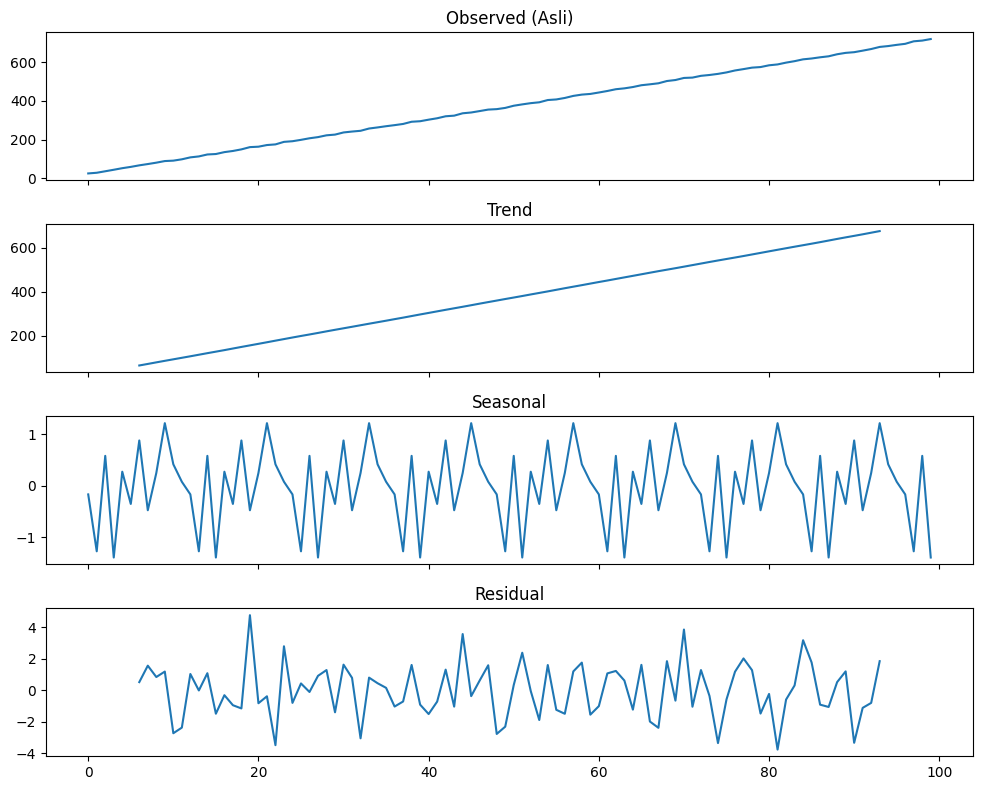

In [467]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

**Jawab:** Berdasarkan hasil dekomposisi deret waktu, data terdiri atas komponen trend, seasonal, dan residual. Komponen observed menunjukkan adanya peningkatan nilai yang konsisten sepanjang periode pengamatan. Komponen trend memperlihatkan pola peningkatan yang hampir linear, sehingga menunjukkan bahwa terdapat kecenderungan jangka panjang yang positif. Sementara itu, komponen seasonal menunjukkan pola naik-turun yang berulang secara periodik, yang mengindikasikan adanya pengaruh musiman dalam data. Besarnya fluktuasi seasonal relatif kecil dibandingkan dengan komponen trend. Selanjutnya, komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola sistematis yang jelas. Hal ini menunjukkan bahwa variasi utama dalam data telah cukup banyak dijelaskan oleh komponen trend dan seasonal, sedangkan sisanya merupakan variasi yang bersifat tidak teratur.

In [468]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

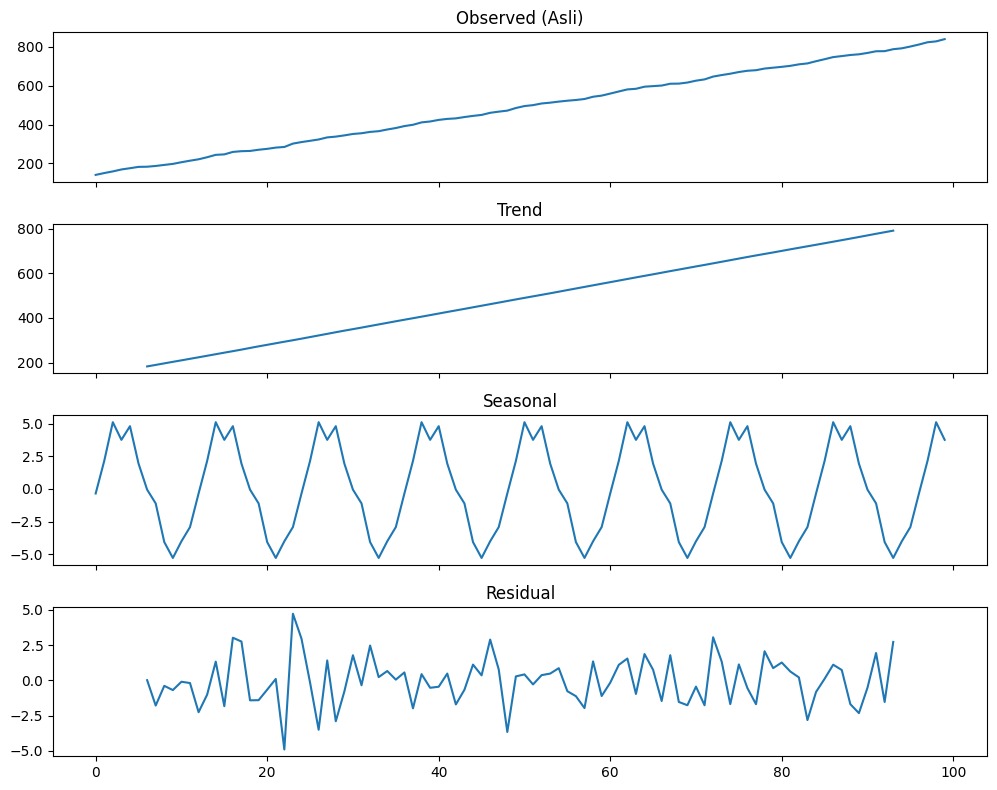

In [469]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

**Jawab:** Berdasarkan hasil dekomposisi deret waktu, data menunjukkan adanya tiga komponen utama, yaitu trend, seasonal, dan residual. Komponen observed menunjukkan peningkatan nilai yang konsisten sepanjang periode pengamatan. Komponen trend memperlihatkan pola peningkatan yang hampir linear, yang menunjukkan adanya kecenderungan jangka panjang positif pada data. Komponen seasonal menunjukkan pola yang berulang secara teratur setiap 12 periode, dengan fluktuasi sekitar -5 hingga +5, sehingga mengindikasikan adanya pola musiman bulanan yang cukup jelas. Sementara itu, komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola sistematis tertentu. Dengan demikian, deret waktu tersebut memiliki karakteristik berupa trend positif yang kuat dan pola musiman yang berulang, sedangkan variasi yang tidak dapat dijelaskan oleh kedua komponen tersebut relatif kecil dan bersifat acak.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [470]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05*14, 10*14 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

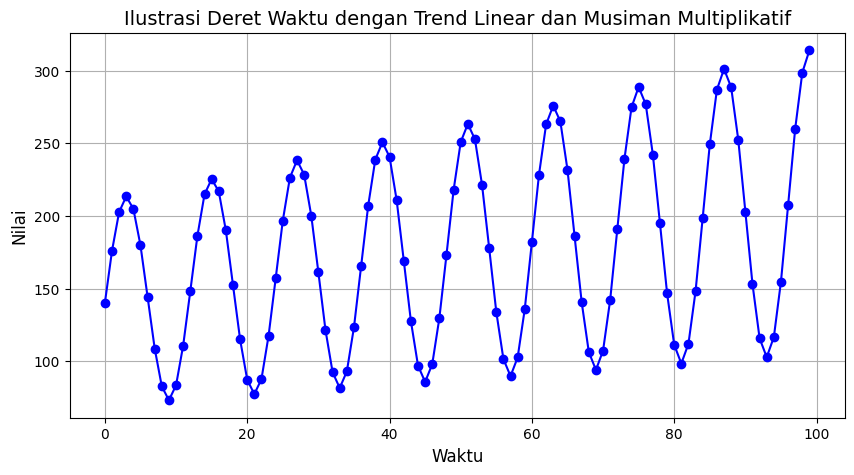

In [471]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [472]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

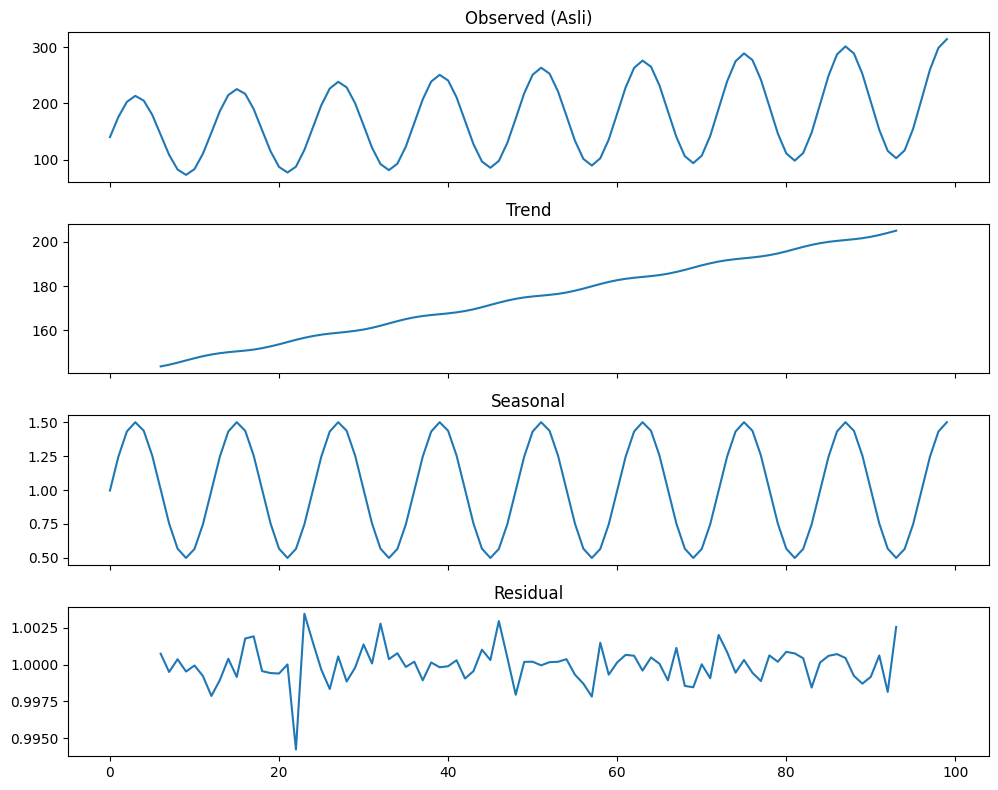

In [473]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?**

**Jawab:** Berdasarkan hasil dekomposisi deret waktu, komponen observed menunjukkan adanya fluktuasi yang berulang secara periodik disertai kecenderungan peningkatan nilai dari waktu ke waktu. Komponen trend menunjukkan pola peningkatan secara bertahap, yang mengindikasikan adanya pertumbuhan jangka panjang pada deret waktu. Sementara itu, komponen seasonal menunjukkan pola yang sangat jelas, teratur, dan berulang pada setiap siklus pengamatan. Hal ini menunjukkan bahwa faktor musiman memiliki pengaruh yang kuat terhadap perubahan nilai aktual. Komponen residual menunjukkan fluktuasi yang relatif kecil dan tidak membentuk pola sistematis, sehingga dapat dikatakan bahwa sebagian besar pola pada data telah dijelaskan oleh komponen trend dan seasonal. Dengan demikian, deret waktu ini memiliki karakteristik utama berupa trend positif dan pola musiman yang kuat, dengan variasi residual yang relatif kecil.

In [474]:
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

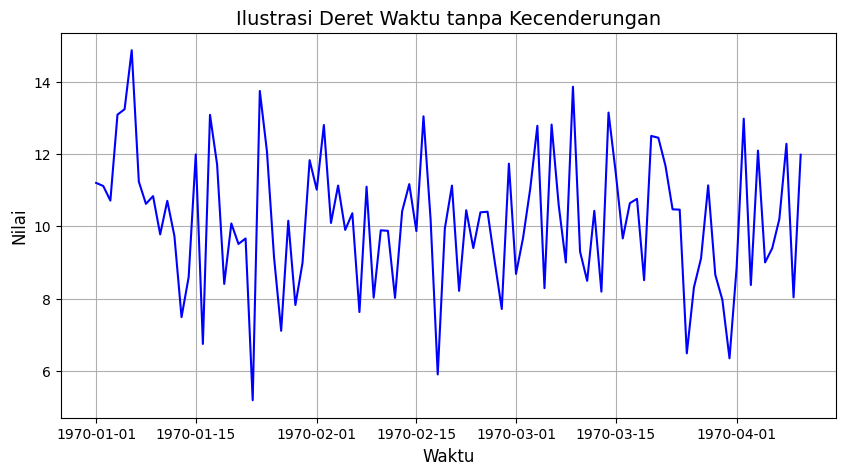

In [475]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

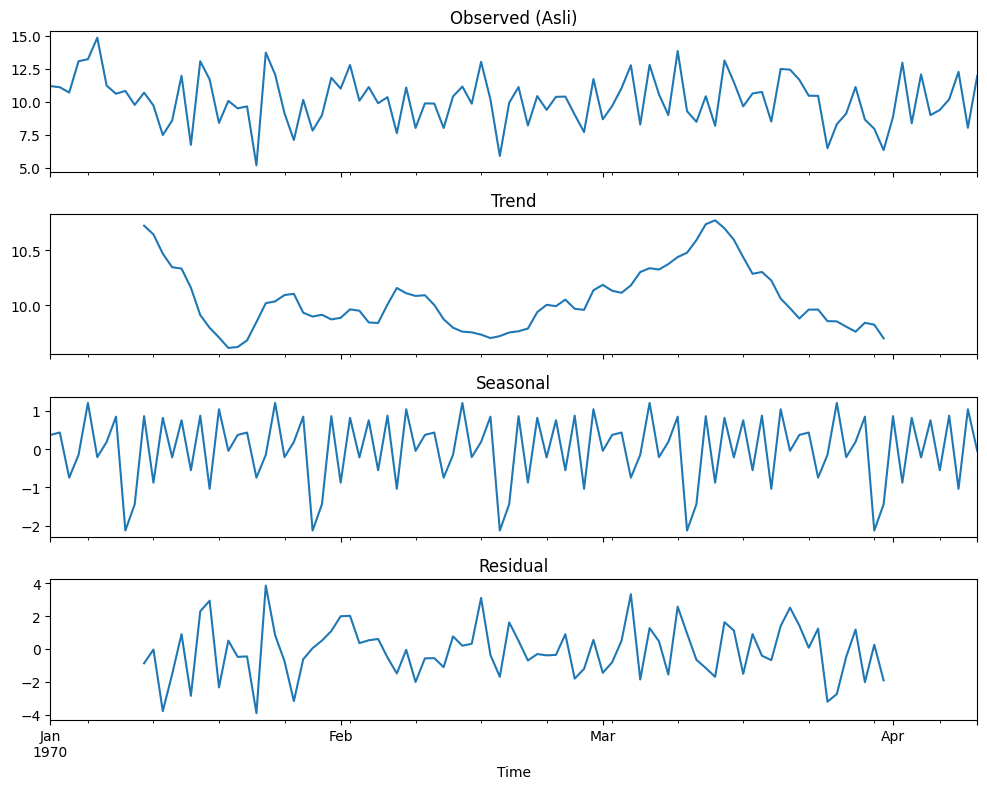

In [476]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi dari plot tersebut?**

**Jawab:** Berdasarkan hasil dekomposisi deret waktu, data aktual menunjukkan fluktuasi yang cukup tinggi sepanjang periode pengamatan. Komponen trend menunjukkan pola yang berubah arah, yaitu mengalami penurunan pada awal periode, kemudian meningkat hingga pertengahan periode, dan kembali menurun pada akhir periode. Hal tersebut menunjukkan bahwa deret waktu tidak memiliki trend linear yang konsisten. Komponen seasonal menunjukkan pola naik-turun yang berulang secara teratur, sehingga mengindikasikan adanya pengaruh musiman yang kuat. Apabila data merupakan data harian, pola tersebut mengindikasikan kemungkinan adanya musiman mingguan dengan periode tujuh hari. Sementara itu, komponen residual berfluktuasi di sekitar nol dengan rentang yang relatif cukup besar. Hal ini menunjukkan bahwa masih terdapat variasi yang belum dapat dijelaskan oleh komponen trend dan seasonal.